In [ ]:
# **ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE**

# Main improvements:

# - Strict app-style input and output objects
# - Separation of emergency rules from trajectory model
# - Reason codes and explanations
# - Data quality checks
# - Human-in-the-loop decision payload
# - Caregiver-safe wording
# - Clinician summary
# - Offline-first `share_record` payload
# - Model versioning and audit trail

# Important design principle:
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Any, Literal
import json
import math
import uuid
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)

# %%
MODEL_VERSION = "rehab_trajectory_rules_v0.2.0"
MODEL_FAMILY = "ACCESS-DP Long-Term Trajectory Failure"
OUTPUT_DIR = Path("access_dp_app_ready_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_EHR_PROFILE_PATH = Path("C:/Users/jaymo/Desktop/Desktop/HTA_Internship/USE_CASE_3/uc3_ehr_demo/outputs/rehab_profile_extracted_v2.json")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Model version:", MODEL_VERSION)
print("Output directory:", OUTPUT_DIR.resolve())

Model version: rehab_trajectory_rules_v0.2.0
Output directory: C:\Users\jaymo\Desktop\Desktop\HTA_Internship\USE_CASE_3\access_dp_app_ready_outputs


In [ ]:

# 1. JSON Serialization Helpers

# These helpers prevent app/export failures caused by NumPy, pandas, NaN, or timestamp objects.

def make_json_serializable(obj):
    if obj is None:
        return None

    if isinstance(obj, (str, int, bool)):
        return obj

    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        value = float(obj)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(obj, pd.Timestamp):
        if pd.isna(obj):
            return None
        return obj.isoformat()

    if obj is pd.NaT:
        return None

    if isinstance(obj, dict):
        return {
            str(make_json_serializable(k)): make_json_serializable(v)
            for k, v in obj.items()
        }

    if isinstance(obj, list):
        return [make_json_serializable(x) for x in obj]

    if isinstance(obj, tuple):
        return [make_json_serializable(x) for x in obj]

    if isinstance(obj, set):
        return [make_json_serializable(x) for x in sorted(obj)]

    return str(obj)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_serializable(obj), f, indent=2, ensure_ascii=False)

    print(f"Saved JSON: {path}")

def save_text(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

    print(f"Saved text: {path}")

def load_json(path):
    path = Path(path)

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:

Severity = Literal[
    "none",
    "info",
    "non_emergency",
    "urgent"
]

EventType = Literal[
    "NO_TRAJECTORY_FAILURE",
    "TRAJECTORY_FAILURE_DETECTED",
    "ROM_PLATEAU_TRAJECTORY_FAILURE",
    "LOW_ADHERENCE_BARRIER",
    "PAIN_LIMITED_PROGRESS",
    "FATIGUE_LIMITED_PROGRESS",
    "DATA_QUALITY_WARNING",
    "INSUFFICIENT_DATA",
    "URGENT_SAFETY_ESCALATION"
]

@dataclass
class PatientContext:
    local_patient_id: str
    display_name: str
    age: str
    condition_group: str
    caregiver_name: str
    setting: str
    location_context: str

@dataclass
class EHRRehabContext:
    source_profile_path: str
    complexity_score: int
    complexity_factors: List[Dict[str, Any]]
    mobility_context: List[str] = field(default_factory=list)
    assistive_devices: List[str] = field(default_factory=list)
    known_limitations: List[str] = field(default_factory=list)
    pain_context: bool = False
    spasticity_context: bool = False
    contracture_context: bool = False
    musculoskeletal_context: bool = False
    latest_ehr_relative_day: int = 0

@dataclass
class RehabMetricPlan:
    metric_name: str
    baseline: float
    target: float
    milestones: List[float]
    higher_is_better: bool
    relevance: float

@dataclass
class RehabPlan:
    plan_id: str
    model_version: str
    duration_days: int
    patient: PatientContext
    ehr_context: EHRRehabContext
    metrics: Dict[str, RehabMetricPlan]
    clinician_authored_goals: List[str]
    safety_boundaries: Dict[str, Any]

@dataclass
class DailyRehabLog:
    local_log_id: str
    home_rehab_day: int
    ehr_relative_day: int
    rom_degrees: Optional[float]
    exercise_reps: Optional[float]
    adherence: Optional[float]
    pain_score: Optional[float]
    fatigue_score: Optional[float]
    walking_minutes: Optional[float]
    emergency_symptoms: List[str] = field(default_factory=list)
    caregiver_note: Optional[str] = None

@dataclass
class MetricAnalysis:
    metric_name: str
    final_actual: Optional[float]
    final_expected: Optional[float]
    gap: Optional[float]
    gap_percent: Optional[float]
    recent_slope: Optional[float]
    plateau_days: int
    data_points: int

@dataclass
class DataQualityReport:
    expected_days: int
    logs_available: int
    missing_days: int
    completion_rate: float
    usable_for_decision: bool
    confidence: Literal["low", "moderate", "high"]
    warnings: List[str]

@dataclass
class RehabDecision:
    decision_id: str
    timestamp_local: str
    model_family: str
    model_version: str
    event_type: EventType
    severity: Severity
    requires_human_review: bool
    emergency_threshold_breach: bool
    notification_path: str
    reason_codes: List[str]
    explanation: List[str]
    recommended_action: Dict[str, str]
    data_quality: DataQualityReport
    metric_analyses: Dict[str, MetricAnalysis]
    review_priority_score: float
    audit: Dict[str, Any]

In [4]:
# %% [markdown]
# ## 3. Load EHR Rehab Profile
#
# The extracted EHR profile provides baseline context and risk modifiers.
#
# The daily home logs remain the primary trajectory signal.

# %%
if INPUT_EHR_PROFILE_PATH.exists():
    ehr_payload = load_json(INPUT_EHR_PROFILE_PATH)
    print("Loaded EHR profile:", INPUT_EHR_PROFILE_PATH)
    print("Top-level keys:", list(ehr_payload.keys()))
else:
    ehr_payload = {}
    print("No EHR profile found. Using empty fallback context.")

Loaded EHR profile: C:\Users\jaymo\Desktop\Desktop\HTA_Internship\USE_CASE_3\uc3_ehr_demo\outputs\rehab_profile_extracted_v2.json
Top-level keys: ['ehr_profile_version', 'source_files', 'encounter_timeline', 'merged_profile', 'ml_patient_profile', 'file_level_profiles']


In [5]:
# %% [markdown]
# ## 4. EHR Helper Functions

# %%
def flatten_text_values(obj):
    values = []

    if obj is None:
        return values

    if isinstance(obj, str):
        values.append(obj.lower())

    elif isinstance(obj, dict):
        for value in obj.values():
            values.extend(flatten_text_values(value))

    elif isinstance(obj, list):
        for item in obj:
            values.extend(flatten_text_values(item))

    return values

def payload_contains(payload, keywords):
    text_blob = " ".join(flatten_text_values(payload))
    return any(keyword.lower() in text_blob for keyword in keywords)

def extract_latest_ehr_relative_day(ehr_payload):
    timeline = ehr_payload.get("encounter_timeline", [])

    days = []

    for item in timeline:
        value = item.get("days_from_first_visit")
        try:
            if value is not None:
                days.append(int(float(value)))
        except Exception:
            pass

    if not days:
        return 0

    return max(days)

def calculate_rehab_complexity_score(ehr_payload):
    factors = []

    def add(condition, points, label):
        if condition:
            factors.append({"factor": label, "points": points})

    add(
        payload_contains(ehr_payload, ["stroke", "cva", "hemiparesis", "hemiplegia"]),
        2,
        "Neurologic motor recovery context"
    )

    add(
        payload_contains(ehr_payload, ["spasticity", "spastic", "baclofen", "diazepam", "botox"]),
        2,
        "Tone/spasticity management context"
    )

    add(
        payload_contains(ehr_payload, ["contracture", "limited rom", "range of motion"]),
        2,
        "Contracture or ROM limitation"
    )

    add(
        payload_contains(ehr_payload, ["hip dislocation", "subluxation", "dysplasia", "scoliosis"]),
        2,
        "Musculoskeletal structural limitation"
    )

    add(
        payload_contains(ehr_payload, ["wheelchair", "afo", "stander", "assistive device"]),
        1,
        "Assistive device or mobility equipment"
    )

    add(
        payload_contains(ehr_payload, ["pain", "chronic pain"]),
        1,
        "Pain-relevant rehab context"
    )

    add(
        payload_contains(ehr_payload, ["dvt", "deep vein thrombosis"]),
        1,
        "Vascular risk history"
    )

    add(
        payload_contains(ehr_payload, ["icu", "deconditioning", "hospitalization"]),
        1,
        "Deconditioning or hospitalization context"
    )

    raw_score = sum(f["points"] for f in factors)
    normalized = min(10, raw_score)

    return normalized, factors

def infer_condition_group(ehr_payload):
    if ehr_payload.get("condition_group"):
        return ehr_payload["condition_group"]

    if payload_contains(ehr_payload, ["stroke", "cva", "hemiparesis", "hemiplegia"]):
        return "post_stroke_rehabilitation"

    if payload_contains(ehr_payload, ["cerebral palsy", "spastic quadriplegic"]):
        return "complex_neuromotor_rehabilitation"

    return "general_home_rehabilitation"

def build_ehr_rehab_context(ehr_payload):
    complexity_score, factors = calculate_rehab_complexity_score(ehr_payload)

    assistive_devices = []
    known_limitations = []
    mobility_context = []

    if payload_contains(ehr_payload, ["wheelchair"]):
        assistive_devices.append("wheelchair")

    if payload_contains(ehr_payload, ["afo"]):
        assistive_devices.append("AFO")

    if payload_contains(ehr_payload, ["stander"]):
        assistive_devices.append("stander")

    if payload_contains(ehr_payload, ["balance"]):
        mobility_context.append("balance difficulty")

    if payload_contains(ehr_payload, ["dependent", "assistance", "caregiver"]):
        mobility_context.append("caregiver or assistance context")

    if payload_contains(ehr_payload, ["contracture"]):
        known_limitations.append("contracture context")

    if payload_contains(ehr_payload, ["limited rom", "range of motion"]):
        known_limitations.append("range-of-motion limitation")

    if payload_contains(ehr_payload, ["hip dislocation", "subluxation", "dysplasia"]):
        known_limitations.append("hip structural limitation")

    if payload_contains(ehr_payload, ["scoliosis"]):
        known_limitations.append("scoliosis context")

    return EHRRehabContext(
        source_profile_path=str(INPUT_EHR_PROFILE_PATH),
        complexity_score=complexity_score,
        complexity_factors=factors,
        mobility_context=mobility_context,
        assistive_devices=assistive_devices,
        known_limitations=known_limitations,
        pain_context=payload_contains(ehr_payload, ["pain", "chronic pain"]),
        spasticity_context=payload_contains(ehr_payload, ["spasticity", "spastic", "baclofen", "diazepam", "botox"]),
        contracture_context=payload_contains(ehr_payload, ["contracture"]),
        musculoskeletal_context=payload_contains(ehr_payload, ["hip dislocation", "subluxation", "dysplasia", "scoliosis"]),
        latest_ehr_relative_day=extract_latest_ehr_relative_day(ehr_payload)
    )

ehr_context = build_ehr_rehab_context(ehr_payload)

print(json.dumps(make_json_serializable(asdict(ehr_context)), indent=2))

{
  "source_profile_path": "C:\\Users\\jaymo\\Desktop\\Desktop\\HTA_Internship\\USE_CASE_3\\uc3_ehr_demo\\outputs\\rehab_profile_extracted_v2.json",
  "complexity_score": 10,
  "complexity_factors": [
    {
      "factor": "Neurologic motor recovery context",
      "points": 2
    },
    {
      "factor": "Tone/spasticity management context",
      "points": 2
    },
    {
      "factor": "Contracture or ROM limitation",
      "points": 2
    },
    {
      "factor": "Musculoskeletal structural limitation",
      "points": 2
    },
    {
      "factor": "Assistive device or mobility equipment",
      "points": 1
    },
    {
      "factor": "Pain-relevant rehab context",
      "points": 1
    },
    {
      "factor": "Vascular risk history",
      "points": 1
    },
    {
      "factor": "Deconditioning or hospitalization context",
      "points": 1
    }
  ],
  "mobility_context": [
    "balance difficulty",
    "caregiver or assistance context"
  ],
  "assistive_devices": [
    "whee

In [6]:
# %% [markdown]
# ## 5. Build App-Ready Patient Context

# %%
patient_context = PatientContext(
    local_patient_id="local-james-okafor-demo",
    display_name="James Okafor",
    age="67 years old",
    condition_group=infer_condition_group(ehr_payload),
    caregiver_name="Diane",
    setting="Home-assisted, non-clinical caregiver",
    location_context="Rural Maryland, intermittent connectivity"
)

print(json.dumps(asdict(patient_context), indent=2))

{
  "local_patient_id": "local-james-okafor-demo",
  "display_name": "James Okafor",
  "age": "67 years old",
  "condition_group": "post_stroke_rehabilitation",
  "caregiver_name": "Diane",
  "setting": "Home-assisted, non-clinical caregiver",
  "location_context": "Rural Maryland, intermittent connectivity"
}


In [7]:
# %% [markdown]
# ## 6. Generate App-Ready Rehab Plan
#
# The app-ready plan is structured around metric objects.
#
# In the real app, this should eventually come from:
#
# 1. clinician-authored rehab plan
# 2. EHR baseline context
# 3. patient/caregiver preferences
# 4. model personalization rules

# %%
def get_metric_relevance(ehr_context: EHRRehabContext):
    relevance = {
        "rom_degrees": 0.90,
        "exercise_reps": 0.75,
        "adherence": 0.80,
        "pain_score": 0.70,
        "fatigue_score": 0.55,
        "walking_minutes": 0.65,
    }

    if ehr_context.contracture_context:
        relevance["rom_degrees"] += 0.08

    if ehr_context.pain_context:
        relevance["pain_score"] += 0.12

    if ehr_context.assistive_devices:
        relevance["walking_minutes"] -= 0.15
        relevance["exercise_reps"] += 0.05

    if ehr_context.spasticity_context:
        relevance["rom_degrees"] += 0.05
        relevance["fatigue_score"] += 0.05

    if ehr_context.complexity_score >= 6:
        relevance["pain_score"] += 0.05
        relevance["fatigue_score"] += 0.05

    return {
        key: round(float(min(1.0, max(0.0, value))), 3)
        for key, value in relevance.items()
    }

def generate_milestone_curve(
    start,
    target,
    days,
    complexity_score,
    metric_name
):
    x = np.arange(days)

    complexity_slowdown = 1.0 - min(complexity_score, 10) * 0.035
    complexity_slowdown = max(0.55, complexity_slowdown)

    if metric_name in ["rom_degrees", "walking_minutes"]:
        curve_shape = 1 - np.exp(-x / (days * 0.45 / complexity_slowdown))
    elif metric_name in ["exercise_reps", "adherence"]:
        curve_shape = 1 - np.exp(-x / (days * 0.35 / complexity_slowdown))
    else:
        curve_shape = np.linspace(0, 1, days)

    curve_shape = curve_shape / curve_shape[-1]
    values = start + (target - start) * curve_shape

    return [round(float(v), 2) for v in values]

def build_rehab_plan(
    patient_context: PatientContext,
    ehr_context: EHRRehabContext,
    duration_days=21
):
    metric_relevance = get_metric_relevance(ehr_context)

    baseline_values = {
        "rom_degrees": 42,
        "exercise_reps": 8,
        "adherence": 0.86,
        "pain_score": 3.2,
        "fatigue_score": 4.0,
        "walking_minutes": 5,
    }

    generic_targets = {
        "rom_degrees": 72,
        "exercise_reps": 22,
        "adherence": 0.90,
        "pain_score": 2.0,
        "fatigue_score": 3.0,
        "walking_minutes": 15,
    }

    higher_is_better = {
        "rom_degrees": True,
        "exercise_reps": True,
        "adherence": True,
        "pain_score": False,
        "fatigue_score": False,
        "walking_minutes": True,
    }

    metrics = {}

    for metric_name, baseline in baseline_values.items():
        generic_target = generic_targets[metric_name]

        if higher_is_better[metric_name]:
            gain = generic_target - baseline
            adjusted_gain = gain * (1.0 - ehr_context.complexity_score * 0.025)
            target = baseline + adjusted_gain
        else:
            improvement = baseline - generic_target
            adjusted_improvement = improvement * (1.0 - ehr_context.complexity_score * 0.02)
            target = baseline - adjusted_improvement

        milestones = generate_milestone_curve(
            start=baseline,
            target=target,
            days=duration_days,
            complexity_score=ehr_context.complexity_score,
            metric_name=metric_name
        )

        metrics[metric_name] = RehabMetricPlan(
            metric_name=metric_name,
            baseline=round(float(baseline), 2),
            target=round(float(target), 2),
            milestones=milestones,
            higher_is_better=higher_is_better[metric_name],
            relevance=metric_relevance[metric_name]
        )

    plan = RehabPlan(
        plan_id="ACCESS-DP-REHAB-PLAN-APP-READY-001",
        model_version=MODEL_VERSION,
        duration_days=duration_days,
        patient=patient_context,
        ehr_context=ehr_context,
        metrics=metrics,
        clinician_authored_goals=[
            "Continue daily home PT program.",
            "Improve functional range of motion over 3 weeks.",
            "Maintain adherence without increasing pain or fatigue.",
            "Escalate non-emergently if progress plateaus despite adherence."
        ],
        safety_boundaries={
            "emergency_symptoms": [
                "chest pain",
                "shortness of breath",
                "new facial droop",
                "new weakness",
                "fall with injury",
                "sudden severe pain",
                "loss of consciousness"
            ],
            "non_emergency_escalation": [
                "sustained trajectory failure",
                "9-day plateau",
                "ROM 35% below week-3 milestone",
                "high adherence but limited progress"
            ]
        }
    )

    return plan

rehab_plan = build_rehab_plan(patient_context, ehr_context)

plan_dict = make_json_serializable(asdict(rehab_plan))
print(json.dumps(plan_dict, indent=2)[:3000])

{
  "plan_id": "ACCESS-DP-REHAB-PLAN-APP-READY-001",
  "model_version": "rehab_trajectory_rules_v0.2.0",
  "duration_days": 21,
  "patient": {
    "local_patient_id": "local-james-okafor-demo",
    "display_name": "James Okafor",
    "age": "67 years old",
    "condition_group": "post_stroke_rehabilitation",
    "caregiver_name": "Diane",
    "setting": "Home-assisted, non-clinical caregiver",
    "location_context": "Rural Maryland, intermittent connectivity"
  },
  "ehr_context": {
    "source_profile_path": "C:\\Users\\jaymo\\Desktop\\Desktop\\HTA_Internship\\USE_CASE_3\\uc3_ehr_demo\\outputs\\rehab_profile_extracted_v2.json",
    "complexity_score": 10,
    "complexity_factors": [
      {
        "factor": "Neurologic motor recovery context",
        "points": 2
      },
      {
        "factor": "Tone/spasticity management context",
        "points": 2
      },
      {
        "factor": "Contracture or ROM limitation",
        "points": 2
      },
      {
        "factor": "Muscul

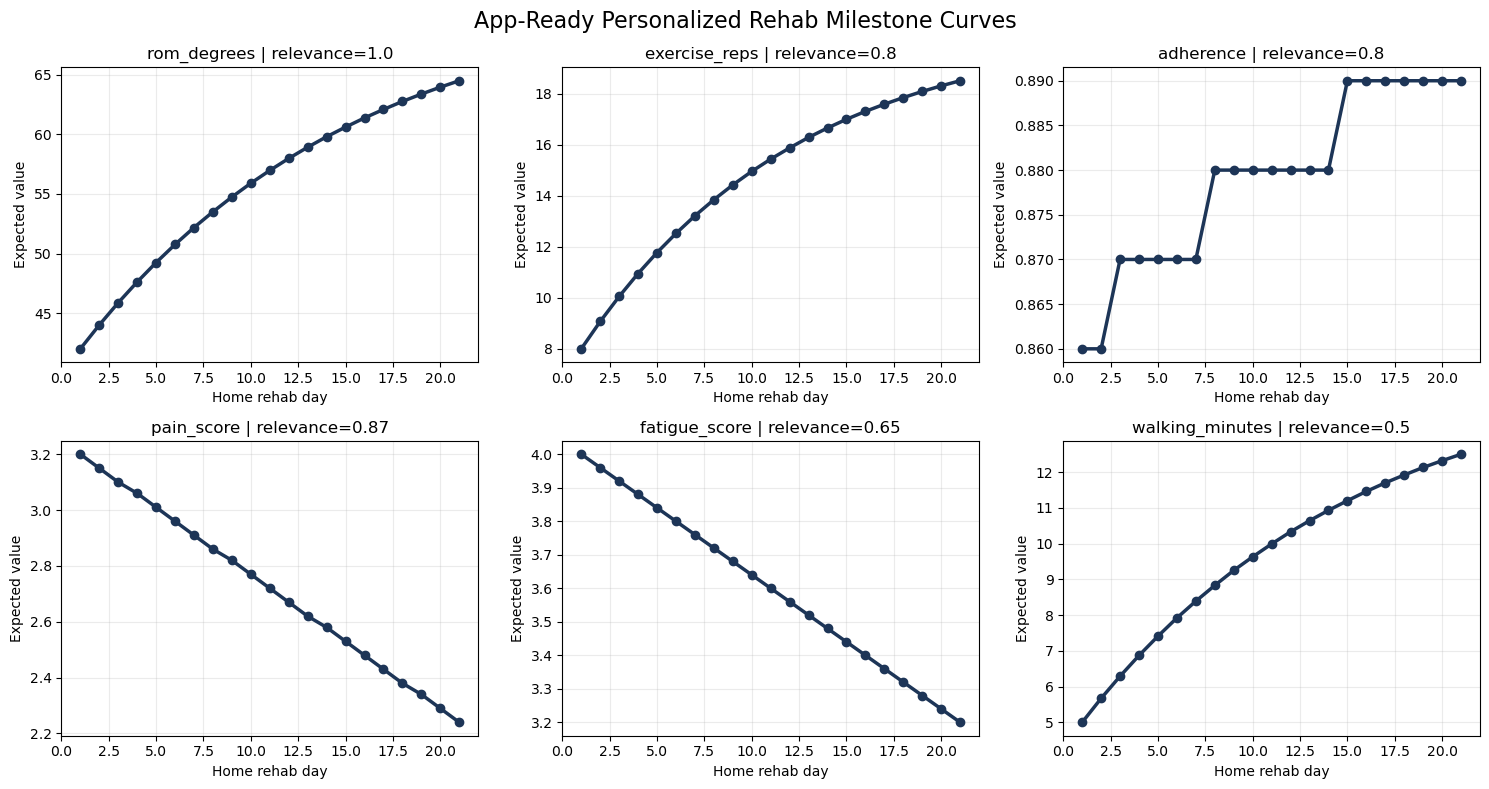

In [8]:
# %% [markdown]
# ## 7. Visualize App-Ready Milestone Plan

# %%
def plot_plan_milestones(plan: RehabPlan):
    days = np.arange(1, plan.duration_days + 1)
    metric_names = list(plan.metrics.keys())

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, metric_name in zip(axes, metric_names):
        metric = plan.metrics[metric_name]

        ax.plot(
            days,
            metric.milestones,
            marker="o",
            linewidth=2.5,
            color="#1D3557"
        )

        ax.set_title(f"{metric_name} | relevance={metric.relevance}")
        ax.set_xlabel("Home rehab day")
        ax.set_ylabel("Expected value")
        ax.grid(alpha=0.25)

    for ax in axes[len(metric_names):]:
        ax.axis("off")

    fig.suptitle("App-Ready Personalized Rehab Milestone Curves", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_plan_milestones(rehab_plan)

In [9]:
# %% [markdown]
# ## 8. Generate Synthetic App Logs
#
# This simulates caregiver-entered daily logs from the mobile app.
#
# Scenario:
#
# - high adherence
# - no emergency symptoms
# - ROM improves early, then plateaus
# - trajectory failure should be detected

# %%
def generate_synthetic_app_logs(
    plan: RehabPlan,
    seed=42,
    scenario="trajectory_failure"
):
    rng = np.random.default_rng(seed)

    logs = []
    latest_ehr_day = plan.ehr_context.latest_ehr_relative_day

    for day in range(1, plan.duration_days + 1):
        ehr_relative_day = latest_ehr_day + day

        if scenario == "trajectory_failure":
            adherence = float(np.clip(rng.normal(0.91, 0.035), 0.78, 1.0))

            if day <= 8:
                rom = 42 + day * 1.1 + rng.normal(0, 0.8)
            elif day <= 12:
                rom = 51 + rng.normal(0, 0.7)
            else:
                rom = 52 + rng.normal(0, 0.6)

            reps = min(18, 8 + day * 0.45 + rng.normal(0, 1.0))
            pain = float(np.clip(rng.normal(3.0, 0.45), 1.5, 5.0))
            fatigue = float(np.clip(rng.normal(4.2, 0.55), 2.5, 6.5))
            walking = min(10, 5 + day * 0.18 + rng.normal(0, 0.7))
            emergency_symptoms = []

        elif scenario == "low_adherence":
            adherence = float(np.clip(rng.normal(0.45, 0.15), 0.0, 0.75))
            rom = 42 + day * 0.35 + rng.normal(0, 1.0)
            reps = 6 + day * 0.2 + rng.normal(0, 1.0)
            pain = float(np.clip(rng.normal(3.5, 0.6), 1.5, 6.0))
            fatigue = float(np.clip(rng.normal(4.5, 0.8), 2.0, 7.0))
            walking = 4 + day * 0.1 + rng.normal(0, 0.6)
            emergency_symptoms = []

        elif scenario == "urgent":
            adherence = float(np.clip(rng.normal(0.85, 0.05), 0.6, 1.0))
            rom = 42 + day * 0.8 + rng.normal(0, 1.0)
            reps = 8 + day * 0.3 + rng.normal(0, 1.0)
            pain = 8.5 if day == 14 else float(np.clip(rng.normal(3.5, 0.8), 1.5, 6.0))
            fatigue = float(np.clip(rng.normal(4.5, 0.8), 2.0, 7.0))
            walking = 5 + day * 0.1 + rng.normal(0, 0.6)
            emergency_symptoms = ["sudden severe pain"] if day == 14 else []

        elif scenario == "normal_progress":
            adherence = float(np.clip(rng.normal(0.90, 0.04), 0.75, 1.0))
            expected_rom = plan.metrics["rom_degrees"].milestones[day - 1]
            rom = expected_rom + rng.normal(0, 1.0)
            reps = plan.metrics["exercise_reps"].milestones[day - 1] + rng.normal(0, 1.0)
            pain = plan.metrics["pain_score"].milestones[day - 1] + rng.normal(0, 0.3)
            fatigue = plan.metrics["fatigue_score"].milestones[day - 1] + rng.normal(0, 0.4)
            walking = plan.metrics["walking_minutes"].milestones[day - 1] + rng.normal(0, 0.8)
            emergency_symptoms = []

        else:
            raise ValueError(f"Unknown scenario: {scenario}")

        log = DailyRehabLog(
            local_log_id=f"log-{day:03d}",
            home_rehab_day=day,
            ehr_relative_day=ehr_relative_day,
            rom_degrees=round(float(rom), 2),
            exercise_reps=round(float(reps), 2),
            adherence=round(float(adherence), 3),
            pain_score=round(float(pain), 2),
            fatigue_score=round(float(fatigue), 2),
            walking_minutes=round(float(walking), 2),
            emergency_symptoms=emergency_symptoms,
            caregiver_note=None
        )

        logs.append(log)

    return logs

daily_logs = generate_synthetic_app_logs(
    rehab_plan,
    seed=RANDOM_SEED,
    scenario="trajectory_failure"
)

daily_logs_df = pd.DataFrame([asdict(x) for x in daily_logs])
display(daily_logs_df.head())
display(daily_logs_df.tail())

,local_log_id,home_rehab_day,ehr_relative_day,rom_degrees,exercise_reps,adherence,pain_score,fatigue_score,walking_minutes,emergency_symptoms,caregiver_note
0,log-001,1,6199,42.27,9.20,0.921,3.42,3.13,4.27,[],None
1,log-002,2,6200,43.95,8.88,0.914,2.62,4.68,5.90,[],None
2,log-003,3,6201,46.20,9.82,0.912,2.61,4.40,4.87,[],None
3,log-004,4,6202,46.36,9.62,0.941,2.69,4.87,5.61,[],None
4,log-005,5,6203,47.22,10.78,0.895,3.16,4.43,6.20,[],None


,local_log_id,home_rehab_day,ehr_relative_day,rom_degrees,exercise_reps,adherence,pain_score,fatigue_score,walking_minutes,emergency_symptoms,caregiver_note
16,log-017,17,6215,51.40,16.05,0.864,2.59,3.99,8.97,[],None
17,log-018,18,6216,52.44,15.17,0.898,2.91,3.68,8.00,[],None
18,log-019,19,6217,50.96,16.98,0.939,3.11,3.87,7.41,[],None
19,log-020,20,6218,51.68,17.23,0.913,3.01,5.08,8.43,[],None
20,log-021,21,6219,52.11,17.67,0.874,3.61,4.66,9.03,[],None


,local_log_id,home_rehab_day,ehr_relative_day,rom_degrees,exercise_reps,adherence,pain_score,fatigue_score,walking_minutes,emergency_symptoms,caregiver_note,rom_degrees_expected,exercise_reps_expected,adherence_expected,pain_score_expected,fatigue_score_expected,walking_minutes_expected
0,log-001,1,6199,42.27,9.20,0.921,3.42,3.13,4.27,[],None,42.00,8.00,0.86,3.20,4.00,5.00
1,log-002,2,6200,43.95,8.88,0.914,2.62,4.68,5.90,[],None,44.00,9.07,0.86,3.15,3.96,5.67
2,log-003,3,6201,46.20,9.82,0.912,2.61,4.40,4.87,[],None,45.87,10.05,0.87,3.10,3.92,6.29
3,log-004,4,6202,46.36,9.62,0.941,2.69,4.87,5.61,[],None,47.61,10.95,0.87,3.06,3.88,6.87
4,log-005,5,6203,47.22,10.78,0.895,3.16,4.43,6.20,[],None,49.24,11.77,0.87,3.01,3.84,7.41


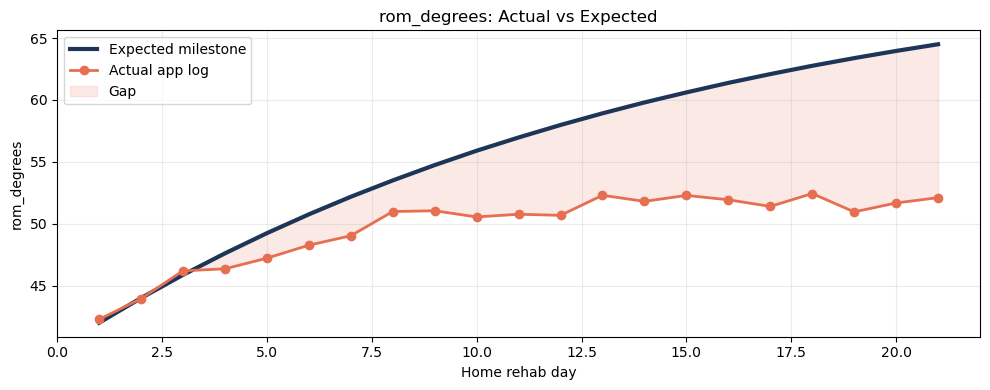

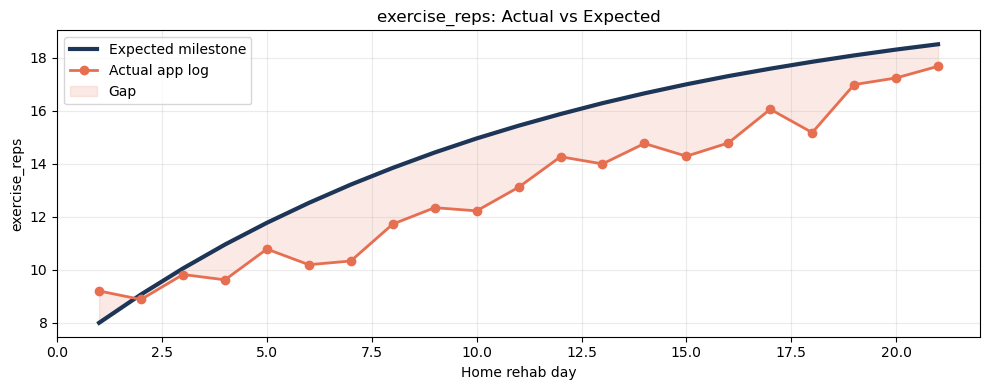

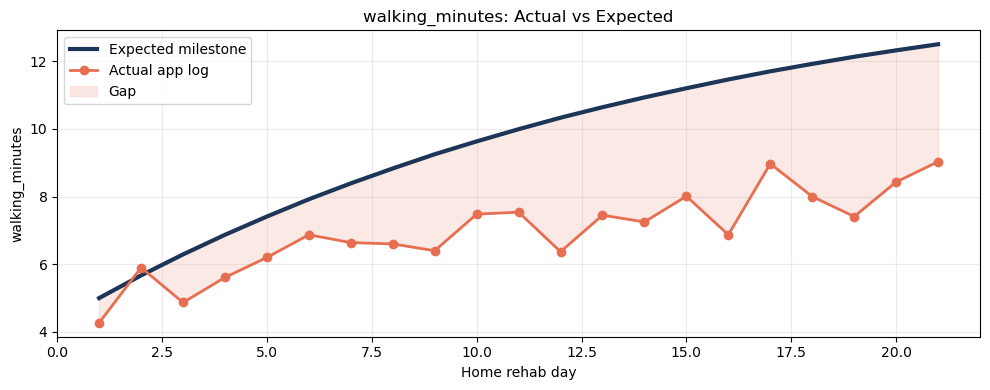

In [10]:
# %% [markdown]
# ## 9. Plot Actual App Logs vs Expected Plan

# %%
def logs_to_dataframe(logs: List[DailyRehabLog], plan: RehabPlan):
    rows = []

    for log in logs:
        row = asdict(log)

        day_index = log.home_rehab_day - 1

        for metric_name, metric_plan in plan.metrics.items():
            expected_value = metric_plan.milestones[day_index]
            row[f"{metric_name}_expected"] = expected_value

        rows.append(row)

    return pd.DataFrame(rows)

analysis_df = logs_to_dataframe(daily_logs, rehab_plan)
display(analysis_df.head())

def plot_actual_vs_expected(df, metric_name):
    actual_col = metric_name
    expected_col = f"{metric_name}_expected"

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        df["home_rehab_day"],
        df[expected_col],
        linewidth=3,
        color="#1D3557",
        label="Expected milestone"
    )

    ax.plot(
        df["home_rehab_day"],
        df[actual_col],
        marker="o",
        linewidth=2,
        color="#E76F51",
        label="Actual app log"
    )

    ax.fill_between(
        df["home_rehab_day"],
        df[actual_col],
        df[expected_col],
        color="#E76F51",
        alpha=0.15,
        label="Gap"
    )

    ax.set_title(f"{metric_name}: Actual vs Expected")
    ax.set_xlabel("Home rehab day")
    ax.set_ylabel(metric_name)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_actual_vs_expected(analysis_df, "rom_degrees")
plot_actual_vs_expected(analysis_df, "exercise_reps")
plot_actual_vs_expected(analysis_df, "walking_minutes")

In [11]:
# %% [markdown]
# ## 10. Safety Rules
#
# Emergency or urgent symptoms are handled outside the trajectory model.
#
# This keeps safety logic separate from ML or statistical scoring.

# %%
NORMALIZED_EMERGENCY_SYMPTOMS = {
    "chest pain",
    "shortness of breath",
    "new facial droop",
    "new weakness",
    "fall with injury",
    "sudden severe pain",
    "loss of consciousness"
}

def normalize_symptom(symptom):
    return str(symptom).strip().lower()

def check_emergency_rules(logs: List[DailyRehabLog]):
    triggered = []

    for log in logs:
        for symptom in log.emergency_symptoms:
            normalized = normalize_symptom(symptom)

            if normalized in NORMALIZED_EMERGENCY_SYMPTOMS:
                triggered.append(
                    {
                        "home_rehab_day": log.home_rehab_day,
                        "ehr_relative_day": log.ehr_relative_day,
                        "symptom": symptom
                    }
                )

        if log.pain_score is not None and log.pain_score >= 8:
            triggered.append(
                {
                    "home_rehab_day": log.home_rehab_day,
                    "ehr_relative_day": log.ehr_relative_day,
                    "symptom": "pain_score >= 8"
                }
            )

    return triggered

emergency_findings = check_emergency_rules(daily_logs)
print("Emergency findings:", emergency_findings)

Emergency findings: []


In [12]:
# %% [markdown]
# ## 11. Data Quality Checks
#
# The model should not overconfidently alert when data is missing or insufficient.

# %%
def evaluate_data_quality(
    logs: List[DailyRehabLog],
    expected_days: int,
    minimum_logs_required=7
):
    available_days = sorted(set(log.home_rehab_day for log in logs))
    logs_available = len(available_days)
    missing_days = expected_days - logs_available
    completion_rate = logs_available / expected_days if expected_days else 0.0

    warnings = []

    if logs_available < minimum_logs_required:
        warnings.append("Not enough logs are available for trajectory evaluation.")

    if completion_rate < 0.70:
        warnings.append("Daily logging completion rate is below 70%.")

    required_metrics = [
        "rom_degrees",
        "exercise_reps",
        "adherence",
        "pain_score",
        "fatigue_score"
    ]

    for metric in required_metrics:
        missing_metric_count = sum(
            getattr(log, metric) is None
            for log in logs
        )

        if missing_metric_count > 0:
            warnings.append(f"{metric} is missing in {missing_metric_count} log(s).")

    usable = logs_available >= minimum_logs_required and completion_rate >= 0.70

    if completion_rate >= 0.90:
        confidence = "high"
    elif completion_rate >= 0.70:
        confidence = "moderate"
    else:
        confidence = "low"

    return DataQualityReport(
        expected_days=expected_days,
        logs_available=logs_available,
        missing_days=missing_days,
        completion_rate=round(float(completion_rate), 3),
        usable_for_decision=bool(usable),
        confidence=confidence,
        warnings=warnings
    )

data_quality = evaluate_data_quality(daily_logs, rehab_plan.duration_days)
print(json.dumps(make_json_serializable(asdict(data_quality)), indent=2))

{
  "expected_days": 21,
  "logs_available": 21,
  "missing_days": 0,
  "completion_rate": 1.0,
  "usable_for_decision": true,
  "confidence": "high",
  "warnings": []
}


In [33]:
# %% [markdown]
# ## 12. Metric Trajectory Analysis

# %%
def linear_slope(values):
    values = np.array(values, dtype=float)
    x = np.arange(len(values), dtype=float)

    if len(values) < 2:
        return 0.0

    return float(np.polyfit(x, values, 1)[0])

def count_plateau_days(
    values: List[float],
    min_days: int = 9,
    slope_threshold: float = 0.20,
    range_threshold: float = 5.0
) -> int:
    """
    Detect recent plateau using trend, not exact day-to-day equality.

    This is intended for home rehab logs where values may jitter day to day.
    A plateau is detected when the recent window has either:
      1. A small absolute linear slope, OR
      2. A small overall range.

    Returns the number of recent days considered plateaued.
    """

    clean_values = [
        float(v)
        for v in values
        if v is not None and not pd.isna(v)
    ]

    if len(clean_values) < min_days:
        return 0

    # If all 9 recent days are trend-flat, this returns 9.
    # If 10+ days are trend-flat, this can return more than 9.
    for window_size in range(len(clean_values), min_days - 1, -1):
        recent = clean_values[-window_size:]

        x = np.arange(window_size, dtype=float)
        y = np.array(recent, dtype=float)

        slope = float(np.polyfit(x, y, 1)[0])
        value_range = float(np.max(y) - np.min(y))

        slope_is_flat = abs(slope) <= slope_threshold
        range_is_flat = value_range <= range_threshold

        if slope_is_flat or range_is_flat:
            return int(window_size)

    return 0

def get_plateau_settings(metric_name: str):
    """
    Metric-specific plateau settings.

    Plateau is only clinically meaningful for selected metrics in this demo.

    - ROM plateau is the main trajectory failure signal.
    - Adherence plateau can show stable participation.
    - Pain/fatigue/walking are handled through gap, trend, and persistence,
      not through plateau_days.
    """

    if metric_name == "rom_degrees":
        return {
            "enabled": True,
            "min_days": 9,
            "slope_threshold": 0.20,
            "range_threshold": 5.0
        }

    if metric_name == "adherence":
        return {
            "enabled": True,
            "min_days": 9,
            "slope_threshold": 0.01,
            "range_threshold": 0.08
        }

    return {
        "enabled": False,
        "min_days": 9,
        "slope_threshold": 0.0,
        "range_threshold": 0.0
    }

def get_log_metric_value(log: DailyRehabLog, metric_name: str):
    return getattr(log, metric_name)

def analyze_metric_trajectory(
    logs: List[DailyRehabLog],
    plan: RehabPlan,
    metric_name: str,
    recent_window=9
):
    metric_plan = plan.metrics[metric_name]

    valid_pairs = []

    for log in logs:
        value = get_log_metric_value(log, metric_name)

        if value is None:
            continue

        day_index = log.home_rehab_day - 1

        if day_index < 0 or day_index >= len(metric_plan.milestones):
            continue

        expected = metric_plan.milestones[day_index]
        valid_pairs.append((log.home_rehab_day, float(value), float(expected)))

    if not valid_pairs:
        return MetricAnalysis(
            metric_name=metric_name,
            final_actual=None,
            final_expected=None,
            gap=None,
            gap_percent=None,
            recent_slope=None,
            plateau_days=0,
            data_points=0
        )

    _, actual_values, expected_values = zip(*valid_pairs)

    actual_values = np.array(actual_values, dtype=float)
    expected_values = np.array(expected_values, dtype=float)

    final_actual = float(actual_values[-1])
    final_expected = float(expected_values[-1])

    if metric_plan.higher_is_better:
        gap = final_expected - final_actual
    else:
        gap = final_actual - final_expected

    if final_expected == 0:
        gap_percent = 0.0
    else:
        gap_percent = gap / abs(final_expected)

    recent_values = actual_values[-recent_window:]
    recent_slope = linear_slope(recent_values)

    plateau_settings = get_plateau_settings(metric_name)

    if plateau_settings["enabled"]:
        plateau_days = count_plateau_days(
            recent_values,
            min_days=plateau_settings["min_days"],
            slope_threshold=plateau_settings["slope_threshold"],
            range_threshold=plateau_settings["range_threshold"]
        )
    else:
        plateau_days = 0

    return MetricAnalysis(
        metric_name=metric_name,
        final_actual=round(final_actual, 2),
        final_expected=round(final_expected, 2),
        gap=round(float(gap), 2),
        gap_percent=round(float(gap_percent), 3),
        recent_slope=round(float(recent_slope), 3),
        plateau_days=int(plateau_days),
        data_points=len(actual_values)
    )

metric_analyses = {
    metric_name: analyze_metric_trajectory(daily_logs, rehab_plan, metric_name)
    for metric_name in rehab_plan.metrics.keys()
}

metric_analysis_df = pd.DataFrame([
    asdict(value) for value in metric_analyses.values()
])

display(metric_analysis_df)

,metric_name,final_actual,final_expected,gap,gap_percent,recent_slope,plateau_days,data_points
0,rom_degrees,52.11,64.50,12.39,0.192,-0.055,9,21
1,exercise_reps,17.67,18.50,0.83,0.045,0.465,0,21
2,adherence,0.87,0.89,0.02,0.018,0.001,9,21
3,pain_score,3.61,2.24,1.37,0.612,0.038,0,21
4,fatigue_score,4.66,3.20,1.46,0.456,0.087,0,21
5,walking_minutes,9.03,12.50,3.47,0.278,0.163,0,21


In [35]:
# %% [markdown]
# ## 13. Review Priority Score
#
# This is not the primary trigger.
#
# The rules determine whether human review is required.
#
# The score is used for prioritization/explanation only.

# %%
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_review_priority_score(
    rom_gap_percent,
    plateau_days,
    adherence_recent,
    pain_recent,
    complexity_score
):
    """
    App-safe interpretation:
    This is a review priority score, not an autonomous medical diagnosis.
    """

    rom_gap_percent = max(0.0, float(rom_gap_percent or 0.0))
    plateau_days = max(0, int(plateau_days or 0))
    adherence_recent = float(adherence_recent or 0.0)
    pain_recent = float(pain_recent or 0.0)
    complexity_score = float(complexity_score or 0.0)

    z = -2.2

    z += 7.5 * rom_gap_percent
    z += 0.32 * plateau_days
    z += 2.0 * max(0, adherence_recent - 0.80)
    z += 0.10 * max(0, pain_recent - 3)
    z += 0.12 * complexity_score

    return float(sigmoid(z))

def average_recent_metric(logs: List[DailyRehabLog], metric_name, window=7):
    values = [
        getattr(log, metric_name)
        for log in logs[-window:]
        if getattr(log, metric_name) is not None
    ]

    if not values:
        return None

    return float(np.mean(values))

rom_analysis = metric_analyses["rom_degrees"]
recent_adherence = average_recent_metric(daily_logs, "adherence", window=7)
recent_pain = average_recent_metric(daily_logs, "pain_score", window=7)

review_priority_score = calculate_review_priority_score(
    rom_gap_percent=rom_analysis.gap_percent,
    plateau_days=rom_analysis.plateau_days,
    adherence_recent=recent_adherence,
    pain_recent=recent_pain,
    complexity_score=rehab_plan.ehr_context.complexity_score
)

print("Recent adherence:", recent_adherence)
print("Recent pain:", recent_pain)
print("Review priority score:", round(review_priority_score, 3))

Recent adherence: 0.8984285714285714
Recent pain: 3.028571428571428
Review priority score: 0.971


In [47]:
# %% [markdown]
# ## 14. App-Ready Decision Engine
#
# This is the core logic that you will later translate into TypeScript.

# %%
def evaluate_rehab_trajectory(
    plan: RehabPlan,
    logs: List[DailyRehabLog]
):
    decision_id = str(uuid.uuid4())
    timestamp_local = dt.datetime.now().isoformat(timespec="seconds")

    emergency_findings = check_emergency_rules(logs)

    data_quality = evaluate_data_quality(
        logs=logs,
        expected_days=plan.duration_days,
        minimum_logs_required=7
    )

    metric_analyses = {
        metric_name: analyze_metric_trajectory(logs, plan, metric_name)
        for metric_name in plan.metrics.keys()
    }

    reason_codes = []
    explanation = []

    recent_adherence = average_recent_metric(logs, "adherence", window=7)
    recent_pain = average_recent_metric(logs, "pain_score", window=7)
    recent_fatigue = average_recent_metric(logs, "fatigue_score", window=7)

    rom = metric_analyses["rom_degrees"]

    review_priority_score = calculate_review_priority_score(
        rom_gap_percent=rom.gap_percent,
        plateau_days=rom.plateau_days,
        adherence_recent=recent_adherence,
        pain_recent=recent_pain,
        complexity_score=plan.ehr_context.complexity_score
    )

    audit = {
        "input_log_count": len(logs),
        "model_version": MODEL_VERSION,
        "thresholds_used": {
            "minimum_logs_required": 7,
            "minimum_completion_rate": 0.70,
            "high_adherence_threshold": 0.80,
            "rom_gap_threshold": 0.35,
            "plateau_days_threshold": 9,
            "pain_limited_threshold": 6.5,
            "fatigue_limited_threshold": 6.0,
            "urgent_pain_threshold": 8.0
        },
        "emergency_findings": emergency_findings,
        "recent_adherence": recent_adherence,
        "recent_pain": recent_pain,
        "recent_fatigue": recent_fatigue
    }

    # 1. Emergency rules bypass trajectory model
    if emergency_findings:
        reason_codes.append("EMERGENCY_SYMPTOM_REPORTED")
        explanation.append(
            "One or more urgent symptoms were reported in the home rehab logs."
        )

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="URGENT_SAFETY_ESCALATION",
            severity="urgent",
            requires_human_review=True,
            emergency_threshold_breach=True,
            notification_path="urgent_safety_instruction",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Follow urgent care instructions. If symptoms are severe or worsening, call emergency services.",
                "clinician": "Review urgent symptom report and contact patient/caregiver as appropriate."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 2. Insufficient data
    if not data_quality.usable_for_decision:
        reason_codes.append("INSUFFICIENT_DATA")
        explanation.append(
            "Not enough complete home rehab logs are available to evaluate trajectory reliably."
        )

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="INSUFFICIENT_DATA",
            severity="info",
            requires_human_review=False,
            emergency_threshold_breach=False,
            notification_path="continue_logging",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Continue logging daily rehab activity so progress can be evaluated.",
                "clinician": "No review requested from trajectory model due to insufficient data."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 3. Rule features
    high_adherence = bool((recent_adherence or 0) >= 0.80)
    low_adherence = bool((recent_adherence or 0) < 0.60)
    rom_below_threshold = bool((rom.gap_percent or 0) >= 0.18)
    nine_day_plateau = bool(rom.plateau_days >= 9)
    pain_limited = bool((recent_pain or 0) >= 6.5)
    fatigue_limited = bool((recent_fatigue or 0) >= 6.0)

    # 4. Low adherence barrier
    if low_adherence and rom_below_threshold:
        reason_codes.extend([
            "LOW_ADHERENCE",
            "ROM_BELOW_MILESTONE",
            "POSSIBLE_CARE_BARRIER"
        ])

        explanation.extend([
            "Recent exercise completion appears below the expected adherence threshold.",
            "Range of motion is below the expected milestone.",
            "This may reflect a barrier to completing the plan rather than lack of effort."
        ])

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="LOW_ADHERENCE_BARRIER",
            severity="non_emergency",
            requires_human_review=True,
            emergency_threshold_breach=False,
            notification_path="standard_non_emergency_escalation",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Add a note about what made exercises difficult and send for clinician review.",
                "clinician": "Review barriers such as pain, fatigue, schedule, equipment, or caregiver availability."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 5. Pain-limited progress
    if pain_limited and rom_below_threshold:
        reason_codes.extend([
            "PAIN_LIMITED_PROGRESS",
            "ROM_BELOW_MILESTONE",
            "NO_EMERGENCY_THRESHOLD_BREACH"
        ])

        explanation.extend([
            "Recent pain scores are elevated.",
            "Range of motion is below the expected milestone.",
            "No emergency threshold was detected, but pain may be limiting progress."
        ])

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="PAIN_LIMITED_PROGRESS",
            severity="non_emergency",
            requires_human_review=True,
            emergency_threshold_breach=False,
            notification_path="standard_non_emergency_escalation",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Send a note about pain patterns and whether exercises are being limited.",
                "clinician": "Review pain control, exercise tolerance, and whether the rehab plan requires adjustment."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 6. Fatigue-limited progress
    if fatigue_limited and rom_below_threshold:
        reason_codes.extend([
            "FATIGUE_LIMITED_PROGRESS",
            "ROM_BELOW_MILESTONE",
            "NO_EMERGENCY_THRESHOLD_BREACH"
        ])

        explanation.extend([
            "Recent fatigue scores are elevated.",
            "Range of motion is below the expected milestone.",
            "No emergency threshold was detected, but fatigue may be limiting progress."
        ])

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="FATIGUE_LIMITED_PROGRESS",
            severity="non_emergency",
            requires_human_review=True,
            emergency_threshold_breach=False,
            notification_path="standard_non_emergency_escalation",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Send a note about fatigue, rest needs, and when exercises are hardest.",
                "clinician": "Review fatigue burden and whether exercise intensity or timing should be modified."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 7. Intended trajectory failure event
    if high_adherence and rom_below_threshold and nine_day_plateau:
        reason_codes.extend([
            "HIGH_ADHERENCE",
            "ROM_BELOW_MILESTONE",
            "NINE_DAY_PLATEAU",
            "NO_EMERGENCY_THRESHOLD_BREACH"
        ])

        explanation.extend([
            "Exercise completion remained above 80%.",
            "Range of motion is at least 35% below the expected milestone.",
            "Progress has been mostly flat for approximately 9 days.",
            "No emergency symptoms were logged."
        ])

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="TRAJECTORY_FAILURE_DETECTED",
            severity="non_emergency",
            requires_human_review=True,
            emergency_threshold_breach=False,
            notification_path="standard_non_emergency_escalation",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Add any context and send the progress summary for clinician review.",
                "clinician": "Review whether the rehabilitation plan should be modified or whether reassessment is needed."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 8. Data quality warning if usable but not high confidence
    if data_quality.confidence != "high":
        reason_codes.append("DATA_QUALITY_WARNING")
        explanation.append(
            "The logs are usable, but missing data reduces confidence in the trajectory evaluation."
        )

        return RehabDecision(
            decision_id=decision_id,
            timestamp_local=timestamp_local,
            model_family=MODEL_FAMILY,
            model_version=MODEL_VERSION,
            event_type="DATA_QUALITY_WARNING",
            severity="info",
            requires_human_review=False,
            emergency_threshold_breach=False,
            notification_path="continue_monitoring",
            reason_codes=reason_codes,
            explanation=explanation,
            recommended_action={
                "caregiver": "Continue logging consistently.",
                "clinician": "No review requested."
            },
            data_quality=data_quality,
            metric_analyses=metric_analyses,
            review_priority_score=round(float(review_priority_score), 3),
            audit=audit
        )

    # 9. Normal monitoring
    reason_codes.append("CONTINUE_MONITORING")
    explanation.append(
        "Current logs do not meet trajectory failure or safety escalation criteria."
    )

    return RehabDecision(
        decision_id=decision_id,
        timestamp_local=timestamp_local,
        model_family=MODEL_FAMILY,
        model_version=MODEL_VERSION,
        event_type="NO_TRAJECTORY_FAILURE",
        severity="none",
        requires_human_review=False,
        emergency_threshold_breach=False,
        notification_path="continue_monitoring",
        reason_codes=reason_codes,
        explanation=explanation,
        recommended_action={
            "caregiver": "Continue the current home rehabilitation plan and daily logging.",
            "clinician": "No review requested."
        },
        data_quality=data_quality,
        metric_analyses=metric_analyses,
        review_priority_score=round(float(review_priority_score), 3),
        audit=audit
    )

decision = evaluate_rehab_trajectory(rehab_plan, daily_logs)

decision_dict = make_json_serializable(asdict(decision))
print(json.dumps(decision_dict, indent=2))

{
  "decision_id": "15e126d0-677b-4cf1-9a66-98200b8d27f2",
  "timestamp_local": "2026-07-14T13:26:48",
  "model_family": "ACCESS-DP Long-Term Trajectory Failure",
  "model_version": "rehab_trajectory_rules_v0.2.0",
  "event_type": "TRAJECTORY_FAILURE_DETECTED",
  "severity": "non_emergency",
  "requires_human_review": true,
  "emergency_threshold_breach": false,
  "notification_path": "standard_non_emergency_escalation",
  "reason_codes": [
    "HIGH_ADHERENCE",
    "ROM_BELOW_MILESTONE",
    "NINE_DAY_PLATEAU",
    "NO_EMERGENCY_THRESHOLD_BREACH"
  ],
  "explanation": [
    "Exercise completion remained above 80%.",
    "Range of motion is at least 35% below the expected milestone.",
    "Progress has been mostly flat for approximately 9 days.",
    "No emergency symptoms were logged."
  ],
  "recommended_action": {
    "caregiver": "Add any context and send the progress summary for clinician review.",
    "clinician": "Review whether the rehabilitation plan should be modified or whet

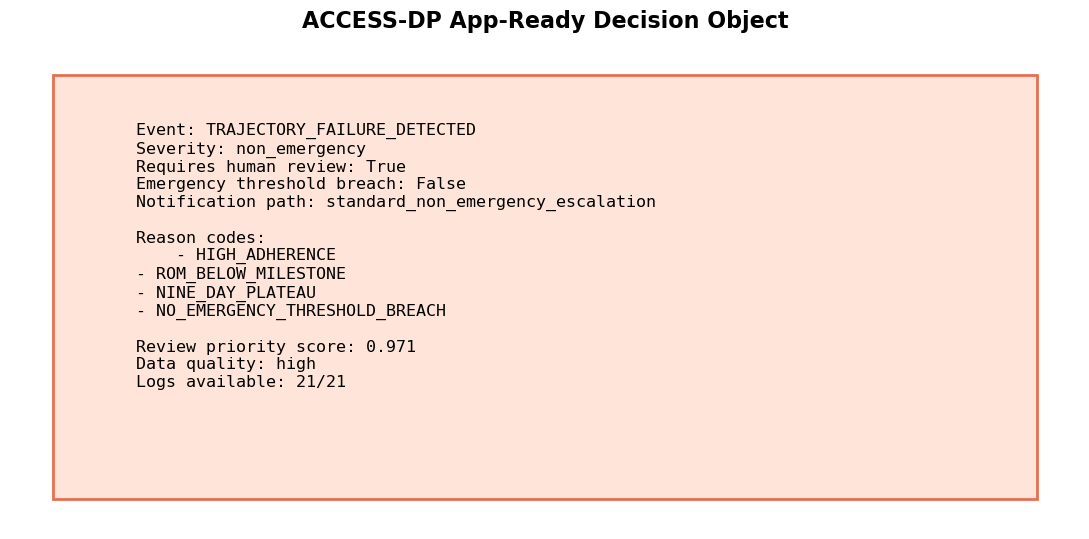

In [49]:
# %% [markdown]
# ## 15. Decision Summary Card

# %%
def draw_decision_card(decision: RehabDecision):
    color_map = {
        "urgent": "#FFCCD5",
        "non_emergency": "#FFE5D9",
        "info": "#E9ECEF",
        "none": "#D8F3DC"
    }

    edge_map = {
        "urgent": "#9D0208",
        "non_emergency": "#E76F51",
        "info": "#6C757D",
        "none": "#2D6A4F"
    }

    color = color_map.get(decision.severity, "#E9ECEF")
    edge = edge_map.get(decision.severity, "#6C757D")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.axis("off")

    rect = plt.Rectangle(
        (0.04, 0.06),
        0.92,
        0.86,
        facecolor=color,
        edgecolor=edge,
        linewidth=2
    )
    ax.add_patch(rect)

    text = f"""
    Event: {decision.event_type}
    Severity: {decision.severity}
    Requires human review: {decision.requires_human_review}
    Emergency threshold breach: {decision.emergency_threshold_breach}
    Notification path: {decision.notification_path}

    Reason codes:
    {chr(10).join("    - " + code for code in decision.reason_codes)}

    Review priority score: {decision.review_priority_score}
    Data quality: {decision.data_quality.confidence}
    Logs available: {decision.data_quality.logs_available}/{decision.data_quality.expected_days}
    """

    ax.text(
        0.08,
        0.86,
        text,
        va="top",
        fontsize=12,
        family="monospace"
    )

    ax.set_title(
        "ACCESS-DP App-Ready Decision Object",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

draw_decision_card(decision)

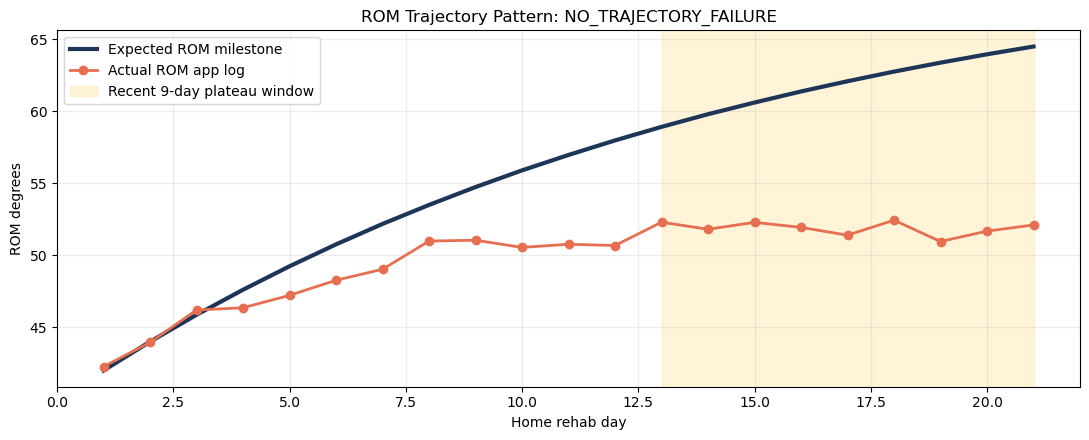

In [41]:
# %% [markdown]
# ## 16. Plateau Visualization

# %%
def plot_rom_plateau(df, decision: RehabDecision):
    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.plot(
        df["home_rehab_day"],
        df["rom_degrees_expected"],
        label="Expected ROM milestone",
        linewidth=3,
        color="#1D3557"
    )

    ax.plot(
        df["home_rehab_day"],
        df["rom_degrees"],
        label="Actual ROM app log",
        marker="o",
        linewidth=2,
        color="#E76F51"
    )

    plateau_window = df.tail(9)

    ax.axvspan(
        plateau_window["home_rehab_day"].min(),
        plateau_window["home_rehab_day"].max(),
        color="#FFD166",
        alpha=0.25,
        label="Recent 9-day plateau window"
    )

    ax.set_title(f"ROM Trajectory Pattern: {decision.event_type}")
    ax.set_xlabel("Home rehab day")
    ax.set_ylabel("ROM degrees")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_rom_plateau(analysis_df, decision)

In [51]:
# %% [markdown]
# ## 17. Caregiver Message
#
# The caregiver message should:
#
# - avoid blame
# - clearly separate emergency from non-emergency
# - explain why the alert happened
# - give a simple next step

# %%
def build_caregiver_message(decision: RehabDecision, plan: RehabPlan):
    name = plan.patient.display_name
    caregiver = plan.patient.caregiver_name

    if decision.event_type == "URGENT_SAFETY_ESCALATION":
        return f"""
ACCESS-DP safety message

{caregiver}, one or more urgent symptoms were reported for {name}.

This may need urgent medical attention. If symptoms are severe, worsening, or concerning,
call emergency services or follow the emergency plan provided by the care team.

Reason:
{chr(10).join("- " + item for item in decision.explanation)}
""".strip()

    if decision.event_type == "TRAJECTORY_FAILURE_DETECTED":
        return f"""
ACCESS-DP progress check

{caregiver}, {name} has been logging rehabilitation activity consistently.

The app noticed that progress is not matching the expected recovery path.
This does not appear to be an emergency based on the information entered.

What the app noticed:
{chr(10).join("- " + item for item in decision.explanation)}

Recommended next step:
{decision.recommended_action["caregiver"]}

You do not need to call emergency services based on this alert alone unless there are new severe symptoms,
a fall with injury, chest pain, shortness of breath, sudden severe pain, or other urgent concerns.
""".strip()

    if decision.event_type == "LOW_ADHERENCE_BARRIER":
        return f"""
ACCESS-DP progress check

{caregiver}, the app noticed that some rehab activity may have been difficult to complete.

This message is not meant to blame you or {name}. Missed or limited sessions can happen because of pain,
fatigue, scheduling, equipment issues, or other barriers.

What the app noticed:
{chr(10).join("- " + item for item in decision.explanation)}

Recommended next step:
{decision.recommended_action["caregiver"]}
""".strip()

    if decision.event_type in ["PAIN_LIMITED_PROGRESS", "FATIGUE_LIMITED_PROGRESS"]:
        return f"""
ACCESS-DP progress check

{caregiver}, the app noticed that {name}'s progress may be limited by symptoms such as pain or fatigue.

This does not appear to be an emergency based on the information entered, but the rehab plan may need review.

What the app noticed:
{chr(10).join("- " + item for item in decision.explanation)}

Recommended next step:
{decision.recommended_action["caregiver"]}
""".strip()

    if decision.event_type == "INSUFFICIENT_DATA":
        return f"""
ACCESS-DP logging reminder

There is not enough information yet to evaluate {name}'s rehabilitation progress.

Recommended next step:
{decision.recommended_action["caregiver"]}
""".strip()

    return f"""
ACCESS-DP progress update

{name}'s current logs do not show a non-emergency trajectory failure at this time.

Recommended next step:
{decision.recommended_action["caregiver"]}
""".strip()

caregiver_message = build_caregiver_message(decision, rehab_plan)
print(caregiver_message)

ACCESS-DP progress check

Diane, James Okafor has been logging rehabilitation activity consistently.

The app noticed that progress is not matching the expected recovery path.
This does not appear to be an emergency based on the information entered.

What the app noticed:
- Exercise completion remained above 80%.
- Range of motion is at least 35% below the expected milestone.
- Progress has been mostly flat for approximately 9 days.
- No emergency symptoms were logged.

Recommended next step:
Add any context and send the progress summary for clinician review.

You do not need to call emergency services based on this alert alone unless there are new severe symptoms,
a fall with injury, chest pain, shortness of breath, sudden severe pain, or other urgent concerns.


In [45]:
# %% [markdown]
# ## 18. Clinician Summary

# %%
def build_clinician_summary(decision: RehabDecision, plan: RehabPlan):
    rom = decision.metric_analyses["rom_degrees"]

    ehr_context_lines = []

    for factor in plan.ehr_context.complexity_factors:
        ehr_context_lines.append(f"{factor['factor']} ({factor['points']} pts)")

    if not ehr_context_lines:
        ehr_context_lines.append("No major EHR-derived rehab modifiers detected.")

    summary = f"""
ACCESS-DP clinician trajectory review

Use case:
ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE

Patient:
{plan.patient.display_name}, {plan.patient.age}
Condition group: {plan.patient.condition_group}
Setting: {plan.patient.setting}
Caregiver: {plan.patient.caregiver_name}
Location context: {plan.patient.location_context}

Decision:
Event type: {decision.event_type}
Severity: {decision.severity}
Requires human review: {decision.requires_human_review}
Emergency threshold breach: {decision.emergency_threshold_breach}
Notification path: {decision.notification_path}

Trajectory findings:
- ROM final actual: {rom.final_actual}
- ROM final expected: {rom.final_expected}
- ROM gap percent: {rom.gap_percent}
- ROM plateau days: {rom.plateau_days}
- Review priority score: {decision.review_priority_score}
- Data quality: {decision.data_quality.confidence}
- Logs available: {decision.data_quality.logs_available}/{decision.data_quality.expected_days}

Reason codes:
{chr(10).join("- " + code for code in decision.reason_codes)}

Explanation:
{chr(10).join("- " + item for item in decision.explanation)}

EHR-derived rehab context:
- Complexity score: {plan.ehr_context.complexity_score}/10
{chr(10).join("- " + item for item in ehr_context_lines)}

Recommended clinician action:
{decision.recommended_action["clinician"]}

Model/audit:
- Model version: {decision.model_version}
- Decision ID: {decision.decision_id}
- Timestamp local: {decision.timestamp_local}
""".strip()

    return summary

clinician_summary = build_clinician_summary(decision, rehab_plan)
print(clinician_summary)

ACCESS-DP clinician trajectory review

Use case:
ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE

Patient:
James Okafor, 67 years old
Condition group: post_stroke_rehabilitation
Setting: Home-assisted, non-clinical caregiver
Caregiver: Diane
Location context: Rural Maryland, intermittent connectivity

Decision:
Event type: NO_TRAJECTORY_FAILURE
Severity: none
Requires human review: False
Emergency threshold breach: False
Notification path: continue_monitoring

Trajectory findings:
- ROM final actual: 52.11
- ROM final expected: 64.5
- ROM gap percent: 0.192
- ROM plateau days: 9
- Review priority score: 0.971
- Data quality: high
- Logs available: 21/21

Reason codes:
- CONTINUE_MONITORING

Explanation:
- Current logs do not meet trajectory failure or safety escalation criteria.

EHR-derived rehab context:
- Complexity score: 10/10
- Neurologic motor recovery context (2 pts)
- Tone/spasticity management context (2 pts)
- Contracture or ROM limitation (2 pts)
- Musculoskeletal str

In [53]:
# %% [markdown]
# ## 19. Offline-First `share_record` Payload
#
# This is the payload concept that can be queued locally and synced later.
#
# Preserved ACCESS-DP references:
#
# - `share_record`
# - `JSON-RPC 2.0`
# - `FHIR R4`
# - `AES-GCM-256 ciphertext bundle`
# - `Signal Protocol / Double Ratchet Algorithm`
# - `SQLCipher`
# - `iOS Keychain / Android Keystore`

# %%
def build_share_record_payload(
    decision: RehabDecision,
    plan: RehabPlan,
    logs: List[DailyRehabLog],
    caregiver_message: str,
    clinician_summary: str
):
    payload = {
        "jsonrpc": "2.0",
        "method": "share_record",
        "params": {
            "event_type": decision.event_type,
            "severity": decision.severity,
            "requires_human_review": decision.requires_human_review,
            "transport_profile": {
                "format": "FHIR R4",
                "envelope": "JSON-RPC 2.0",
                "encryption": "AES-GCM-256 ciphertext bundle",
                "session_security": "Signal Protocol / Double Ratchet Algorithm",
                "local_storage": "SQLCipher",
                "key_storage": "iOS Keychain / Android Keystore"
            },
            "offline_first": {
                "created_offline": True,
                "detection_requires_network": False,
                "queued_for_sync": bool(decision.requires_human_review),
                "sync_when_connectivity_returns": bool(decision.requires_human_review)
            },
            "patient": asdict(plan.patient),
            "plan_id": plan.plan_id,
            "model_version": decision.model_version,
            "decision": asdict(decision),
            "caregiver_message": caregiver_message,
            "clinician_summary": clinician_summary,
            "relative_timeline": {
                "latest_ehr_relative_day": plan.ehr_context.latest_ehr_relative_day,
                "home_rehab_day_start": min(log.home_rehab_day for log in logs),
                "home_rehab_day_end": max(log.home_rehab_day for log in logs),
                "ehr_relative_day_start": min(log.ehr_relative_day for log in logs),
                "ehr_relative_day_end": max(log.ehr_relative_day for log in logs)
            }
        },
        "id": f"share-record-{decision.decision_id}"
    }

    return payload

share_record_payload = build_share_record_payload(
    decision=decision,
    plan=rehab_plan,
    logs=daily_logs,
    caregiver_message=caregiver_message,
    clinician_summary=clinician_summary
)

print(json.dumps(make_json_serializable(share_record_payload), indent=2)[:4000])

{
  "jsonrpc": "2.0",
  "method": "share_record",
  "params": {
    "event_type": "TRAJECTORY_FAILURE_DETECTED",
    "severity": "non_emergency",
    "requires_human_review": true,
    "transport_profile": {
      "format": "FHIR R4",
      "envelope": "JSON-RPC 2.0",
      "encryption": "AES-GCM-256 ciphertext bundle",
      "session_security": "Signal Protocol / Double Ratchet Algorithm",
      "local_storage": "SQLCipher",
      "key_storage": "iOS Keychain / Android Keystore"
    },
    "offline_first": {
      "created_offline": true,
      "detection_requires_network": false,
      "queued_for_sync": true,
      "sync_when_connectivity_returns": true
    },
    "patient": {
      "local_patient_id": "local-james-okafor-demo",
      "display_name": "James Okafor",
      "age": "67 years old",
      "condition_group": "post_stroke_rehabilitation",
      "caregiver_name": "Diane",
      "setting": "Home-assisted, non-clinical caregiver",
      "location_context": "Rural Maryland, in

In [55]:
# %% [markdown]
# ## 20. Scenario Tests
#
# These tests are important before converting to TypeScript.
#
# We test:
#
# 1. intended trajectory failure
# 2. low adherence barrier
# 3. urgent safety escalation
# 4. normal progress

# %%
def run_scenario_test(scenario_name):
    logs = generate_synthetic_app_logs(
        rehab_plan,
        seed=RANDOM_SEED,
        scenario=scenario_name
    )

    decision = evaluate_rehab_trajectory(rehab_plan, logs)

    return {
        "scenario": scenario_name,
        "event_type": decision.event_type,
        "severity": decision.severity,
        "requires_human_review": decision.requires_human_review,
        "emergency_threshold_breach": decision.emergency_threshold_breach,
        "reason_codes": decision.reason_codes,
        "review_priority_score": decision.review_priority_score,
        "data_quality": decision.data_quality.confidence
    }

scenario_results = [
    run_scenario_test("trajectory_failure"),
    run_scenario_test("low_adherence"),
    run_scenario_test("urgent"),
    run_scenario_test("normal_progress")
]

scenario_results_df = pd.DataFrame(scenario_results)
display(scenario_results_df)

,scenario,event_type,severity,requires_human_review,emergency_threshold_breach,reason_codes,review_priority_score,data_quality
0,trajectory_failure,TRAJECTORY_FAILURE_DETECTED,non_emergency,True,False,"[HIGH_ADHERENCE, ROM_BELOW_MILESTONE, NINE_DAY_PLATEAU, NO_EMERGENCY_THRESHOLD_BREACH]",0.971,high
1,low_adherence,LOW_ADHERENCE_BARRIER,non_emergency,True,False,"[LOW_ADHERENCE, ROM_BELOW_MILESTONE, POSSIBLE_CARE_BARRIER]",0.975,high
2,urgent,URGENT_SAFETY_ESCALATION,urgent,True,True,[EMERGENCY_SYMPTOM_REPORTED],0.473,high
3,normal_progress,NO_TRAJECTORY_FAILURE,none,False,False,[CONTINUE_MONITORING],0.304,high


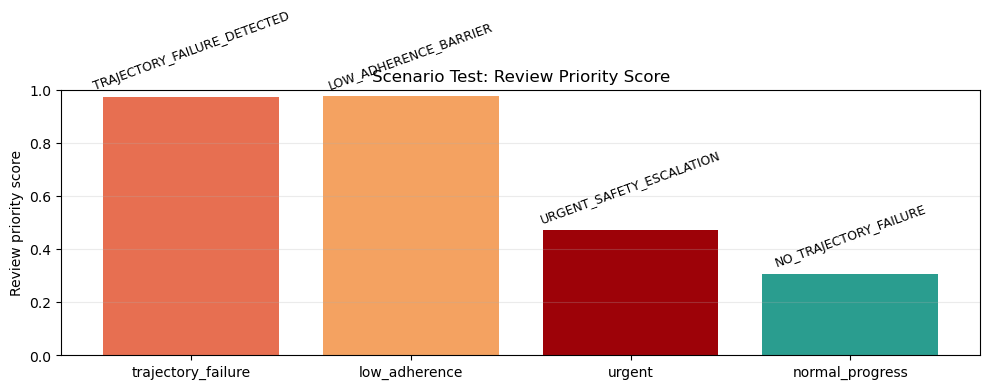

In [57]:
# %% [markdown]
# ## 21. Visual Scenario Comparison

# %%
fig, ax = plt.subplots(figsize=(10, 4))

colors = {
    "TRAJECTORY_FAILURE_DETECTED": "#E76F51",
    "LOW_ADHERENCE_BARRIER": "#F4A261",
    "URGENT_SAFETY_ESCALATION": "#9D0208",
    "NO_TRAJECTORY_FAILURE": "#2A9D8F"
}

bar_colors = [
    colors.get(event, "#6C757D")
    for event in scenario_results_df["event_type"]
]

ax.bar(
    scenario_results_df["scenario"],
    scenario_results_df["review_priority_score"],
    color=bar_colors
)

ax.set_ylim(0, 1)
ax.set_title("Scenario Test: Review Priority Score")
ax.set_ylabel("Review priority score")
ax.grid(axis="y", alpha=0.25)

for i, row in scenario_results_df.iterrows():
    ax.text(
        i,
        row["review_priority_score"] + 0.03,
        row["event_type"],
        ha="center",
        rotation=20,
        fontsize=9
    )

plt.tight_layout()
plt.show()